# LLM Agents — Семинар

**Практическая часть:**
1. Агент на **LangChain** + Mistral
2. Агент на **LangGraph** + Mistral
3. Агент на **smolagents** + Mistral (через LiteLLM)
4. **Мультиагентная система** на LangGraph + Mistral

In [1]:
!pip install langchain langchain-mistralai langgraph smolagents mistralai ddgs requests wikipedia

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.4/60.4 kB 837.4 kB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 155.7/155.7 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 990.5/990.5 kB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.1/67.1 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 16.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 543.9/543.9 kB 16.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 220.0/220.0 kB 16.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.4/66.4 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 30.9 MB/s eta 0:00:00
  Created wheel for wikipedia: filename=wikipedia-1.4.0-py3-none-any.whl size=11678 sha256=42a48a80e49cc3cc44862fcb665be202e668726e6ef91f6cf4881ec87b3fdd7a
  Stored in directory: /root/.cache/pip/wheels/63/47/7c/a9688349aa74d228ce0a9023229c6c

In [2]:
!echo MISTRAL_API_KEY=CKbrN3v3sbyrmbwoSCzV0jCREe4XVivj

MISTRAL_API_KEY=CKbrN3v3sbyrmbwoSCzV0jCREe4XVivj


In [8]:
import os
import re
import json
import requests
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

MISTRAL_API_KEY = "JJZuUVCxoi3grvphWmHiwQvM8AgTkwAy" #os.environ['MISTRAL_API_KEY']""

<img alt="" width="400" align="center" src="data:image/png;base64,
..." />

<img alt="" width="700" align="center" src="data:image/png;base64, ..."/>

---
## Часть 1. LangChain + Mistral

Три инструмента с реальными бесплатными API:
- **Open-Meteo Geocoding** — координаты города по названию (без ключа)
- **Open-Meteo Weather** — погода (без ключа)
- **ExchangeRate-API** — курсы валют (без ключа)
- **DuckDuckGo** — веб-поиск (без ключа)

### Геокодинг

Координаты города берём из Open-Meteo Geocoding API — никакого хардкода.

In [9]:
def get_coords(city):
    url  = f'https://geocoding-api.open-meteo.com/v1/search?name={city}&count=1&language=en&format=json'
    data = requests.get(url).json()
    r    = data['results'][0]
    return r['latitude'], r['longitude'], r['name'], r['country']

print(get_coords('Tokyo'))
print(get_coords('Moscow'))

(35.6895, 139.69171, 'Tokyo', 'Japan')
(55.75204, 37.61781, 'Moscow', 'Russia')


### Инструменты

In [10]:
from langchain_core.tools import tool

@tool
def get_weather(city: str) -> str:
    """Текущая погода в городе: температура и скорость ветра. Названия городов СТРОГО на английском"""
    lat, lon, name, country = get_coords(city)
    url  = f'https://api.open-meteo.com/v1/forecast?latitude={lat}&longitude={lon}&current=temperature_2m,wind_speed_10m'
    data = requests.get(url).json()
    temp = data['current']['temperature_2m']
    wind = data['current']['wind_speed_10m']
    return f'{name}, {country}: {temp}°C, ветер {wind} км/ч'

print(get_weather.invoke({'city': 'Paris'}))
print(get_weather.invoke({'city': 'Madrid'}))

Paris, France: 15.6°C, ветер 4.7 км/ч
Madrid, Spain: 17.0°C, ветер 6.2 км/ч


In [11]:
@tool
def convert_currency(amount: float, from_currency: str, to_currency: str) -> str:
    """Конвертировать сумму из одной валюты в другую."""
    url  = f'https://api.exchangerate-api.com/v4/latest/{from_currency.upper()}'
    data = requests.get(url).json()
    rate = data['rates'][to_currency.upper()]
    return f'{amount} {from_currency.upper()} = {amount * rate:.2f} {to_currency.upper()}'

print(convert_currency.invoke({'amount': 100, 'from_currency': 'USD', 'to_currency': 'EUR'}))
print(convert_currency.invoke({'amount': 500, 'from_currency': 'EUR', 'to_currency': 'JPY'}))

100.0 USD = 85.10 EUR
500.0 EUR = 91900.00 JPY


In [12]:
@tool
def web_search(query: str) -> str:
    """Поиск актуальной информации в интернете через DuckDuckGo."""
    from ddgs import DDGS
    with DDGS() as ddgs:
        results = list(ddgs.text(query, max_results=3))
    return '\n'.join(f"- {r['title']}: {r['body'][:150]}" for r in results)

print(web_search.invoke({'query': 'Mistral AI new models 2024'}))

- What is Mistral AI? Everything to know about the... | TechCrunch: Free models include research models such as Mistral NeMo, built in collaboration with Nvidia which the startup open sourced in July 2024. How does Mis
- Org profile for Mistral AI_ on Hugging Face, the AI community building...: Mistral AI - Frontier AI. In Your Hands. We believe in a future where AI is abundant and accessible.Welcome to the official Hugging Face Mistral AI or
- The uncensored Dolphin model based on Mistral that excels at coding...: The Dolphin model by Eric Hartford, based on Mistral version 0.2 released in March 2024. This model is uncensored, available for both commercial and n


### Агент

In [8]:
from langchain_mistralai import ChatMistralAI
from langchain.agents import create_agent

tools = [get_weather, convert_currency, web_search]

llm = ChatMistralAI(model='mistral-small-latest', temperature=0, api_key=MISTRAL_API_KEY)

executor = create_agent(
    llm,
    tools,
    system_prompt='Ты помощник. Используй инструменты для ответа. Отвечай кратко на русском.',
)

/usr/local/lib/python3.12/dist-packages/langgraph/checkpoint/serde/encrypted.py:5: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit value (e.g., allowed_objects='messages' or allowed_objects='core') to suppress this warning.
  from langgraph.checkpoint.serde.jsonplus import JsonPlusSerializer


In [9]:
from langchain_core.messages import HumanMessage

result = executor.invoke({'messages': [HumanMessage(content='Какая сейчас погода в Токио и Лондоне?')]})
print(result['messages'][-1].content)

В **Токио**: 20.0°C, ветер 4.7 км/ч.
В **Лондоне**: 12.9°C, ветер 6.8 км/ч.


In [10]:
result['messages']

[HumanMessage(content='Какая сейчас погода в Токио и Лондоне?', additional_kwargs={}, response_metadata={}, id='4ed273c2-d2db-4ace-a171-952cb74f924b'),
 AIMessage(content='', additional_kwargs={'tool_calls': [{'id': '7d9geYM0p', 'function': {'name': 'get_weather', 'arguments': '{"city": "Tokyo"}'}, 'index': 0}, {'id': 'GWMBXB1kX', 'function': {'name': 'get_weather', 'arguments': '{"city": "London"}'}, 'index': 1}]}, response_metadata={'token_usage': {'prompt_tokens': 294, 'total_tokens': 317, 'completion_tokens': 23, 'prompt_tokens_details': {'cached_tokens': 0}}, 'model_name': 'mistral-small-latest', 'model': 'mistral-small-latest', 'finish_reason': 'tool_calls', 'model_provider': 'mistralai'}, id='lc_run--019e0214-977f-7771-82ff-de408f5f2df8-0', tool_calls=[{'name': 'get_weather', 'args': {'city': 'Tokyo'}, 'id': '7d9geYM0p', 'type': 'tool_call'}, {'name': 'get_weather', 'args': {'city': 'London'}, 'id': 'GWMBXB1kX', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'inpu

In [11]:
result = executor.invoke({'messages': [HumanMessage(content='Сколько стоит 1000 евро в японских йенах? И найди новости про Mistral AI.')]})
print(result['messages'][-1].content)

1000 евро = **183 800 японских йен**.

**Новости о Mistral AI:**
- Вышла новая модель **Mistral Medium 3.5** (128B параметров), объединяющая чат, рассуждение и код.
- На Википедии утверждается, что Mistral 7B превосходит LLaMA 2 13B по всем тестам.
- Последние новости и анонсы компании доступны на [официальном сайте Mistral AI](https://mistral.ai/latest-news/).


In [12]:
result['messages']

[HumanMessage(content='Сколько стоит 1000 евро в японских йенах? И найди новости про Mistral AI.', additional_kwargs={}, response_metadata={}, id='9f76070b-6a19-4c29-988b-4a3095e0f957'),
 AIMessage(content='', additional_kwargs={'tool_calls': [{'id': '2BDRyHmAH', 'function': {'name': 'convert_currency', 'arguments': '{"amount": 1000, "from_currency": "EUR", "to_currency": "JPY"}'}, 'index': 0}, {'id': 'I1Bs72wsa', 'function': {'name': 'web_search', 'arguments': '{"query": "новости про Mistral AI"}'}, 'index': 1}]}, response_metadata={'token_usage': {'prompt_tokens': 309, 'total_tokens': 354, 'completion_tokens': 45, 'prompt_tokens_details': {'cached_tokens': 0}}, 'model_name': 'mistral-small-latest', 'model': 'mistral-small-latest', 'finish_reason': 'tool_calls', 'model_provider': 'mistralai'}, id='lc_run--019e0215-5ffd-7e31-892a-39231829a22e-0', tool_calls=[{'name': 'convert_currency', 'args': {'amount': 1000, 'from_currency': 'EUR', 'to_currency': 'JPY'}, 'id': '2BDRyHmAH', 'type': '

### Бонус: попробуем initialize_agent

In [13]:
!pip install langchain_classic langchain_community 'smolagents[litellm]'

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.6/90.6 kB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 29.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.5/16.5 MB 48.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 41.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 463.6/463.6 kB 25.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.2/98.2 kB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.1/278.1 kB 21.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.5/88.5 kB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 46.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 71.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.9/64.9 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.0/51.0 kB 4.2 

In [31]:
!pip install --upgrade click typer

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 110.5/110.5 kB 1.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.4/58.4 kB 3.0 MB/s eta 0:00:00
  Attempting uninstall: click
    Found existing installation: click 8.3.2
    Uninstalling click-8.3.2:
      Successfully uninstalled click-8.3.2
  Attempting uninstall: typer
    Found existing installation: typer 0.24.2
    Uninstalling typer-0.24.2:
      Successfully uninstalled typer-0.24.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
litellm 1.83.14 requires click==8.1.8, but you have click 8.3.3 which is incompatible.
wikipedia-api 0.14.1 requires click==8.3.2, but you have click 8.3.3 which is incompatible.
google-adk 1.29.0 requires opentelemetry-api<1.39.0,>=1.36.0, but you have opentelemetry-api 1.39.1 which is incompatible.
gradio 5.50.0 requires pydantic<=2.12.3,>=2.0, but you have pydant

In [1]:
MISTRAL_API_KEY = "JJZuUVCxoi3grvphWmHiwQvM8AgTkwAy"

In [2]:
from langchain_mistralai import ChatMistralAI

Запустите функции @tool выше после перезапуска

In [13]:
from langchain_mistralai import ChatMistralAI
from langchain_classic.tools import Tool
from langchain_classic.agents import initialize_agent

tools = [get_weather, convert_currency, web_search]

llm = ChatMistralAI(model='mistral-small-latest', temperature=0, api_key=MISTRAL_API_KEY)

executor = initialize_agent(
    tools=tools,
    llm=llm,
    agent="structured-chat-zero-shot-react-description",
    verbose=True,
    handle_parsing_errors=True,
    max_iterations=3,
)

response = executor.run("Какая погода в Москве?")
print(response)

/tmp/ipykernel_13850/648454436.py:9: LangChainDeprecationWarning: Use `langchain.agents.create_agent` for new applications. It provides a more flexible agent factory with middleware support, structured output, and integration with LangGraph for persistence, streaming, and human-in-the-loop workflows. Migration guide: https://docs.langchain.com/oss/python/migrate/langchain-v1
  executor = initialize_agent(
/tmp/ipykernel_13850/648454436.py:18: LangChainDeprecationWarning: The method `Chain.run` was deprecated in langchain-classic 0.1.0 and will be removed in 2.0.0. Use `invoke` instead.
  response = executor.run("Какая погода в Москве?")




> Entering new AgentExecutor chain...
Action:
```json
{
  "action": "get_weather",
  "action_input": {
    "city": "Moscow"
  }
}
```


Observation: Moscow, Russia: 28.3°C, ветер 14.7 км/ч
Thought:Action:
```json
{
  "action": "Final Answer",
  "action_input": "В Москве сейчас 28.3°C, скорость ветра 14.7 км/ч."
}
```

> Finished chain.
В Москве сейчас 28.3°C, скорость ветра 14.7 км/ч.


---
## Часть 2. LangGraph + Mistral

Делаем граф явным — видно каждый узел и переход.  
Инструменты другие: Wikipedia + калькулятор + статистика текста.

In [6]:
!pip install wikipedia-api -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 582.4 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.1/129.1 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 108.4/108.4 kB 5.4 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
litellm 1.83.14 requires click==8.1.8, but you have click 8.3.2 which is incompatible.
google-adk 1.29.0 requires opentelemetry-api<1.39.0,>=1.36.0, but you have opentelemetry-api 1.39.1 which is incompatible.


In [7]:
import wikipediaapi
from langchain_core.tools import tool

@tool
def wikipedia_search(query, language='ru', sentences=5):
    """
    Агентская функция для Википедии, работает в Google Colab.

    Parameters:
        query (str): Тема для поиска
        language (str): Код языка ('ru', 'en', 'de'...)
        sentences (int): Сколько предложений из summary

    Returns:
        dict: Результат с заголовком, текстом, URL
    """

    wiki = wikipediaapi.Wikipedia(
        user_agent='MyColabProject/1.0 (myemail@example.com)',
        language=language
    )
    page = wiki.page(query)
    summary = page.summary

    if sentences > 0:
        all_sentences = summary.split('. ')
        summary = '. '.join(all_sentences[:sentences])
        if not summary.endswith('.'):
            summary += '.'

    return {
        'status': 'success',
        'title': page.title,
        'text': summary,
        'url': page.fullurl,
        'language': language,
        'sections_count': len(page.sections)
    }

print(wikipedia_search.invoke({"query": "Искусственный интеллект"}))

{'status': 'success', 'title': 'Искусственный интеллект', 'text': 'Иску́сственный интелле́кт (англ. artificial intelligence; AI), также ИИ, искусственный ра́зум, в самом широком смысле — научно-технологическая область, занимающаяся изучением и созданием интеллектуальных сущностей (англ. intelligent entities), способных «вычислять, как им действовать эффективно и безопасно в самых разнообразных, в том числе незнакомых им, ситуациях», и решать задачи как минимум уровня человеческого интеллекта и реализованных машинами, в частности компьютерными системами. Это направление исследований в области компьютерных наук, которая разрабатывает и изучает методы и программное обеспечение, позволяющие машинам воспринимать окружающую среду и использовать обучение и интеллект для выполнения действий, которые максимально увеличивают их шансы на достижение поставленных целей. Такие машины можно назвать искусственным интеллектом.', 'url': 'https://ru.wikipedia.org/wiki/%D0%98%D1%81%D0%BA%D1%83%D1%81%D1%81

In [8]:
import re

@tool
def calculator(expression: str) -> str:
    """Вычислить математическое выражение. Например: '2 ** 32' или '(15 + 27) * 3'."""
    return str(eval(expression, {'__builtins__': {}}, {}))

@tool
def text_stats(text: str) -> str:
    """Посчитать количество слов, символов и предложений в тексте."""
    words     = len(text.split())
    chars     = len(text)
    sentences = len(re.split(r'[.!?]+', text.strip()))
    return f'Слов: {words}, символов: {chars}, предложений: {sentences}'

print(calculator.invoke({'expression': '2 ** 32'}))

4294967296


### Граф

```
START → llm → есть tool_calls → tools → llm → ...
            → нет tool_calls  → END
```

In [9]:
from typing import Annotated, TypedDict
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode
from langchain_core.messages import HumanMessage, AIMessage, SystemMessage
from langchain_mistralai import ChatMistralAI

class State(TypedDict):
    messages: Annotated[list, lambda x, y: x + y]

lg_tools = [wikipedia_search, calculator, text_stats]

mistral = ChatMistralAI(model='mistral-small-latest', temperature=0, api_key=MISTRAL_API_KEY).bind_tools(lg_tools)

def call_model(state):
    system   = SystemMessage(content='Ты исследователь. Используй инструменты. Отвечай на русском.')
    response = mistral.invoke([system] + state['messages'])
    return {'messages': [response]}

def should_continue(state):
    last = state['messages'][-1]
    if isinstance(last, AIMessage) and getattr(last, 'tool_calls', None):
        return 'tools'
    return END

graph = StateGraph(State)
graph.add_node('llm',   call_model)
graph.add_node('tools', ToolNode(lg_tools))
graph.add_edge(START, 'llm')
graph.add_conditional_edges('llm', should_continue)
graph.add_edge('tools', 'llm')

lg_agent = graph.compile()

/usr/local/lib/python3.12/dist-packages/langgraph/cache/base/__init__.py:8: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit value (e.g., allowed_objects='messages' or allowed_objects='core') to suppress this warning.
  from langgraph.checkpoint.serde.jsonplus import JsonPlusSerializer


In [10]:
from langchain_core.messages import ToolMessage

def run_lg(question):
    print(f'Вопрос: {question}\n')
    result = lg_agent.invoke({'messages': [HumanMessage(content=question)]})
    for msg in result['messages']:
        if isinstance(msg, AIMessage) and msg.tool_calls:
            for tc in msg.tool_calls:
                print(f'Input Tool: {tc["name"]}({tc["args"]})')
        elif isinstance(msg, AIMessage) and msg.content:
            print(f'Output Model: {msg.content}')
        elif isinstance(msg, ToolMessage):
            print(f'Output Tool: {msg.name}: {msg.content[:120]}')

In [11]:
run_lg('Что такое трансформер в машинном обучении? Вычисли 2 в степени 40.')

Вопрос: Что такое трансформер в машинном обучении? Вычисли 2 в степени 40.

Input Tool: wikipedia_search({'query': 'трансформер в машинном обучении', 'language': 'ru', 'sentences': 5})
Input Tool: calculator({'expression': '2 ** 40'})
Output Tool: wikipedia_search: {"status": "success", "title": "трансформер в машинном обучении", "text": ".", "url": null, "language": "ru", "sections_
Output Tool: calculator: 1099511627776
Output Model: **Трансформер в машинном обучении** — это архитектура модели, основанная на механизме внимания (attention mechanism), которая позволяет эффективно обрабатывать последовательности данных, такие как текст, звук или изображение. В отличие от рекуррентных нейронных сетей (RNN), трансформеры не используют рекурсию и обрабатывают данные параллельно, что значительно ускоряет обучение и позволяет работать с длинными последовательностями. Они широко применяются в задачах обработки естественного языка (например, в моделях BERT, GPT) и других областях машинного обу

In [12]:
run_lg('Найди статью про Mistral AI и посчитай сколько слов в найденном тексте')

Вопрос: Найди статью про Mistral AI и посчитай сколько слов в найденном тексте

Input Tool: wikipedia_search({'query': 'Mistral AI', 'language': 'ru', 'sentences': 5})
Output Tool: wikipedia_search: {"status": "success", "title": "Mistral AI", "text": "Mistral AI — французский стартап в области искусственного интеллек
Input Tool: text_stats({'text': 'Mistral AI — французский стартап в области искусственного интеллекта, разрабатывающий программное обеспечение с различными инструментами генеративного ИИ. Работает над большими языковыми моделями.'})
Output Tool: text_stats: Слов: 22, символов: 196, предложений: 3
Output Model: В статье про **Mistral AI** содержится **22 слова**.


---
## Часть 3. smolagents + Mistral

smolagents использует **LiteLLM** как бэкенд — через него подключаем Mistral.  
**CodeAgent** генерирует Python-код вместо JSON: за один шаг может вызвать несколько инструментов и обработать результат.

In [13]:
from smolagents import Tool
import requests

class MagicBallTool(Tool):
    name        = 'magic_ball'
    description = 'Получить случайный ответ "да/нет/может быть" на любой вопрос, как магический шар'
    inputs      = {'question': {'type': 'string', 'description': 'Вопрос (любой текст)'}}
    output_type = 'string'

    def forward(self, question):
        response = requests.get(
            'https://yesno.wtf/api',
            timeout=10
        )
        response.raise_for_status()
        data = response.json()

        answer = data.get('answer', 'unknown')
        translations = {
            'yes': 'ДА!',
            'no': 'НЕТ!',
            'maybe': 'МОЖЕТ БЫТЬ'
        }
        return translations.get(answer, answer)

mb = MagicBallTool()
print(mb.forward("Будет ли завтра дождь?"))
print(mb.forward("Стоит ли мне учить Python?"))
print(mb.forward("Я выиграю в лотерею?"))

ДА!
НЕТ!
НЕТ!


In [14]:
class PrimeFactorsTool(Tool):
    name        = 'prime_factors'
    description = 'Разложить число на простые множители'
    inputs      = {'n': {'type': 'integer', 'description': 'Число'}}
    output_type = 'string'

    def forward(self, n):
        factors, d = [], 2
        while d * d <= n:
            while n % d == 0:
                factors.append(d)
                n //= d
            d += 1
        if n > 1:
            factors.append(n)
        return ' × '.join(map(str, factors))

pf = PrimeFactorsTool()
print(pf.forward(360))
print(pf.forward(1024))

2 × 2 × 2 × 3 × 3 × 5
2 × 2 × 2 × 2 × 2 × 2 × 2 × 2 × 2 × 2


In [15]:
from smolagents import CodeAgent, LiteLLMModel

model = LiteLLMModel(
    model_id='mistral/mistral-small-latest',
    api_key=MISTRAL_API_KEY
)

smol_agent = CodeAgent(tools=[mb, pf], model=model, max_steps=4)
result = smol_agent.run('Для чисел 12, 60 и 360: разложи на простые множители и скажи сегодня будет хороший день, что говорит магия?')
print(result)

╭──────────────────────────────────────────────────── New run ────────────────────────────────────────────────────╮
│                                                                                                                 │
│ Для чисел 12, 60 и 360: разложи на простые множители и скажи сегодня будет хороший день, что говорит магия?     │
│                                                                                                                 │
╰─ LiteLLMModel - mistral/mistral-small-latest ───────────────────────────────────────────────────────────────────╯

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ Step 1 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

─ Executing parsed code: ──────────────────────────────────────────────────────────────────────────────────────── 
  # Разложение чисел на простые множители                                                                          
  factors_12 = prime_factors(12)                                                                                   
  factors_60 = prime_factors(60)                                                                                   
  factors_360 = prime_factors(360)                                                                                 
                                                                                                                   
  # Вопрос магическому шару                                                                                        
  today_question = "Будет ли сегодня хороший день?"                                                                
  magic_answer = magic_ball(question=today_question)                                                               
                                                                                                                   
  print(f"Разложение 12 на простые множители: {factors_12}")                                                       
  print(f"Разложение 60 на простые множители: {factors_60}")                                                       
  print(f"Разложение 360 на простые множители: {factors_360}")                                                     
  print(f"Ответ магического шара: {magic_answer}")                                                                 
 ─────────────────────────────────────────────────────────────────────────────────────────────────────────────────

Execution logs:
Разложение 12 на простые множители: 2 × 2 × 3
Разложение 60 на простые множители: 2 × 2 × 3 × 5
Разложение 360 на простые множители: 2 × 2 × 2 × 3 × 3 × 5
Ответ магического шара: ДА!

Out: None

[Step 1: Duration 3.50 seconds| Input tokens: 2,201 | Output tokens: 262]

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ Step 2 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

─ Executing parsed code: ──────────────────────────────────────────────────────────────────────────────────────── 
  final_answer({                                                                                                   
      "Разложение 12 на простые множители": "2 × 2 × 3",                                                           
      "Разложение 60 на простые множители": "2 × 2 × 3 × 5",                                                       
      "Разложение 360 на простые множители": "2 × 2 × 2 × 3 × 3 × 5",                                              
      "Ответ магического шара": "ДА!"                                                                              
  })                                                                                                               
 ─────────────────────────────────────────────────────────────────────────────────────────────────────────────────

Final answer: {'Разложение 12 на простые множители': '2 × 2 × 3', 'Разложение 60 на простые множители': '2 × 2 × 3 
× 5', 'Разложение 360 на простые множители': '2 × 2 × 2 × 3 × 3 × 5', 'Ответ магического шара': 'ДА!'}

[Step 2: Duration 1.43 seconds| Input tokens: 5,010 | Output tokens: 414]

{'Разложение 12 на простые множители': '2 × 2 × 3', 'Разложение 60 на простые множители': '2 × 2 × 3 × 5', 'Разложение 360 на простые множители': '2 × 2 × 2 × 3 × 3 × 5', 'Ответ магического шара': 'ДА!'}


---
## Часть 4. Мультиагентная система на LangGraph + Mistral

**Архитектура: Оркестратор + специализированные агенты**

Оркестратор получает задачу, анализирует её и динамически решает, каким агентам её передать:
- **WikiAgent** — ищет информацию в Википедии
- **SearchAgent** — выполняет веб-поиск через DuckDuckGo
- **CalcAgent** — выполняет математические вычисления и статистику текста

```
START → orchestrator → wiki_agent    → orchestrator → END
                     → search_agent  ↗
                     → calc_agent    ↗
```


<img alt="" width="700" align="center" src="data:image/jpg;base64, ..." />

In [17]:
from typing import Annotated, TypedDict, Literal
from langgraph.graph import StateGraph, START, END
from langchain_core.messages import HumanMessage, AIMessage, SystemMessage, ToolMessage
from langchain_mistralai import ChatMistralAI

class MASState(TypedDict):
    task:         str                     # исходная задача пользователя
    plan:         str                     # план оркестратора
    wiki_result:  str                     # результат WikiAgent
    search_result: str                    # результат SearchAgent
    calc_result:  str                     # результат CalcAgent
    final_answer: str                     # итоговый ответ
    next_agents:  list[str]               # очередь агентов
    messages:     Annotated[list, lambda x, y: x + y]


In [18]:
orchestrator_llm = ChatMistralAI(model='mistral-small-latest', temperature=0, api_key=MISTRAL_API_KEY)

def orchestrator(state: MASState) -> dict:
    """Оркестратор: анализирует задачу и решает, каких агентов вызвать."""
    print('Orchestrator анализирую задачу')

    system = SystemMessage(content="""
Ты — оркестратор мультиагентной системы. У тебя есть три специализированных агента:
- wiki_agent   — ищет информацию в Википедии (факты, определения, биографии)
- search_agent — выполняет актуальный веб-поиск (новости, цены, события)
- calc_agent   — математические вычисления и анализ текста

Проанализируй задачу и выбери нужных агентов. Ответь ТОЛЬКО JSON:
{"plan": "краткий план", "agents": ["wiki_agent", "search_agent", "calc_agent"]}
Включай только тех агентов, которые реально нужны для задачи.
""")
    response = orchestrator_llm.invoke([system, HumanMessage(content=state['task'])])

    text = response.content.strip()
    # убираем markdown-обёртку если есть
    if '```' in text:
        text = text.split('```')[1]
        if text.startswith('json'):
            text = text[4:]
    parsed = json.loads(text)
    plan   = parsed.get('plan', 'Выполнить задачу')
    agents = parsed.get('agents', ['wiki_agent'])

    print(f'План: {plan}')
    print(f'Агенты: {agents}')
    return {'plan': plan, 'next_agents': agents, 'messages': [AIMessage(content=f'[Orchestrator] {plan}')]}


In [26]:
def route_agents(state: MASState) -> list[str]:
    """Маршрутизатор: возвращает список агентов для параллельного запуска."""
    return state['next_agents'] if state['next_agents'] else ['synthesizer']

In [19]:
import wikipediaapi
from langchain_core.tools import tool

@tool
def wikipedia_search(query, language='ru', sentences=5):
    """
    Агентская функция для Википедии, работает в Google Colab.

    Parameters:
        query (str): Тема для поиска
        language (str): Код языка ('ru', 'en', 'de'...)
        sentences (int): Сколько предложений из summary

    Returns:
        dict: Результат с заголовком, текстом, URL
    """

    wiki = wikipediaapi.Wikipedia(
        user_agent='MyColabProject/1.0 (myemail@example.com)',
        language=language
    )
    page = wiki.page(query)
    summary = page.summary

    if sentences > 0:
        all_sentences = summary.split('. ')
        summary = '. '.join(all_sentences[:sentences])
        if not summary.endswith('.'):
            summary += '.'

    return {
        'status': 'success',
        'title': page.title,
        'text': summary,
        'url': page.fullurl,
        'language': language,
        'sections_count': len(page.sections)
    }

@tool
def calculator(expression: str) -> str:
    """Вычислить математическое выражение. Например: '2 ** 32' или '(15 + 27) * 3'."""
    return str(eval(expression, {'__builtins__': {}}, {}))

@tool
def web_search(query: str) -> str:
    """Поиск актуальной информации в интернете через DuckDuckGo."""
    from ddgs import DDGS
    with DDGS() as ddgs:
        results = list(ddgs.text(query, max_results=3))
    return '\n'.join(f"- {r['title']}: {r['body'][:150]}" for r in results)

@tool
def text_stats(text: str) -> str:
    """Посчитать количество слов, символов и предложений в тексте."""
    words     = len(text.split())
    chars     = len(text)
    sentences = len(re.split(r'[.!?]+', text.strip()))
    return f'Слов: {words}, символов: {chars}, предложений: {sentences}'

In [24]:
def run_with_tools(llm_with_tools, tool_map, messages):
    """Вспомогательная функция: гоняет LLM в цикле пока не закончатся tool_calls."""
    while True:
        response = llm_with_tools.invoke(messages)
        messages.append(response)
        if not getattr(response, 'tool_calls', None):
            break
        for tc in response.tool_calls:
            result = tool_map[tc['name']].invoke(tc['args'])
            messages.append(ToolMessage(content=str(result), tool_call_id=tc['id']))
    return response

In [25]:
wiki_llm   = ChatMistralAI(model='mistral-small-latest', temperature=0, api_key=MISTRAL_API_KEY)\
                 .bind_tools([wikipedia_search])
search_llm = ChatMistralAI(model='mistral-small-latest', temperature=0, api_key=MISTRAL_API_KEY)\
                 .bind_tools([web_search])
calc_llm   = ChatMistralAI(model='mistral-small-latest', temperature=0, api_key=MISTRAL_API_KEY)\
                 .bind_tools([calculator, text_stats])


def wiki_agent(state: MASState) -> dict:
    """WikiAgent: ищет информацию в Википедии."""
    print('WikiAgent ищу в Википедии')
    messages = [
        SystemMessage(content='Используй wikipedia_search для поиска информации. Отвечай на русском.'),
        HumanMessage(content=f'Задача: {state["task"]}\nПлан: {state["plan"]}')
    ]
    response = run_with_tools(wiki_llm, {'wikipedia_search': wikipedia_search}, messages)
    return {'wiki_result': response.content, 'messages': [AIMessage(content=f'[WikiAgent] готово')]}


def search_agent(state: MASState) -> dict:
    """SearchAgent: выполняет актуальный веб-поиск."""
    print('SearchAgent ищет')
    messages = [
        SystemMessage(content='Используй web_search для актуального поиска. Отвечай на русском.'),
        HumanMessage(content=f'Задача: {state["task"]}\nПлан: {state["plan"]}')
    ]
    response = run_with_tools(search_llm, {'web_search': web_search}, messages)
    return {'search_result': response.content, 'messages': [AIMessage(content=f'[SearchAgent] готово')]}


def calc_agent(state: MASState) -> dict:
    """CalcAgent: выполняет вычисления и анализ текста."""
    print('CalcAgent считает')
    messages = [
        SystemMessage(content='Используй calculator и text_stats для вычислений. Отвечай на русском.'),
        HumanMessage(content=f'Задача: {state["task"]}\nПлан: {state["plan"]}')
    ]
    response = run_with_tools(calc_llm, {'calculator': calculator, 'text_stats': text_stats}, messages)
    return {'calc_result': response.content, 'messages': [AIMessage(content=f'[CalcAgent] готово')]}

In [22]:
synth_llm = ChatMistralAI(model='mistral-small-latest', temperature=0.3, api_key=MISTRAL_API_KEY)

def synthesizer(state: MASState) -> dict:
    """Оркестратор возвращается и синтезирует финальный ответ из всех результатов."""
    print('Orchestrator формирует ответ')

    parts = [f'Задача: {state["task"]}']
    if state.get('wiki_result'):
        parts.append(f'Wikipedia:\n{state["wiki_result"]}')
    if state.get('search_result'):
        parts.append(f'Веб-поиск:\n{state["search_result"]}')
    if state.get('calc_result'):
        parts.append(f'Вычисления:\n{state["calc_result"]}')

    prompt = '\n\n'.join(parts) + '\n\nСформируй краткий итоговый ответ на русском, объединив все данные.'
    response = synth_llm.invoke([HumanMessage(content=prompt)])
    return {'final_answer': response.content, 'messages': [AIMessage(content='[Orchestrator] ответ готов')]}

In [27]:
mas = StateGraph(MASState)

mas.add_node('orchestrator', orchestrator)
mas.add_node('wiki_agent',   wiki_agent)
mas.add_node('search_agent', search_agent)
mas.add_node('calc_agent',   calc_agent)
mas.add_node('synthesizer',  synthesizer)

mas.add_edge(START, 'orchestrator')

# Оркестратор динамически маршрутизирует к нужным агентам
mas.add_conditional_edges(
    'orchestrator',
    route_agents,
    ['wiki_agent', 'search_agent', 'calc_agent', 'synthesizer']
)

# Все агенты сходятся к синтезатору
mas.add_edge('wiki_agent',   'synthesizer')
mas.add_edge('search_agent', 'synthesizer')
mas.add_edge('calc_agent',   'synthesizer')
mas.add_edge('synthesizer',  END)

mas_graph = mas.compile()

In [28]:
def run_mas(task: str):
    print(f'Задача: {task}')

    result = mas_graph.invoke({
        'task': task,
        'plan': '', 'wiki_result': '', 'search_result': '',
        'calc_result': '', 'final_answer': '', 'next_agents': [],
        'messages': [HumanMessage(content=task)]
    })
    print('ИТОГОВЫЙ ОТВЕТ:')
    print(result['final_answer'])

In [29]:
import json

run_mas('Расскажи про LLM трансформеры, найди свежие новости о Mistral AI и вычисли 2 в степени 20')

Задача: Расскажи про LLM трансформеры, найди свежие новости о Mistral AI и вычисли 2 в степени 20
Orchestrator анализирую задачу
План: 1) Найти определение и описание LLM трансформеров в Википедии. 2) Выполнить веб-поиск свежих новостей о Mistral AI. 3) Вычислить 2 в степени 20 с помощью калькулятора.
Агенты: ['wiki_agent', 'search_agent', 'calc_agent']
CalcAgent считает
SearchAgent ищет
WikiAgent ищу в Википедии
Orchestrator формирует ответ
ИТОГОВЫЙ ОТВЕТ:
### **Итоговый ответ**

#### **1. LLM-трансформеры**
Трансформер — это архитектура глубокого обучения, представленная в 2017 году (статья *"Attention Is All You Need"*), которая произвела революцию в обработке естественного языка. Её ключевые особенности:
- **Механизм внимания (Attention)** позволяет модели фокусироваться на важных частях текста, игнорируя нерелевантные данные.
- **Параллельная обработка** ускоряет обучение по сравнению с RNN.
- **Масштабируемость** позволяет создавать модели с миллиардами параметров (например, GPT,

In [30]:
run_mas('Что такое число Пи? Вычисли 355/113 и сравни с точным значением 3.14159265')

Задача: Что такое число Пи? Вычисли 355/113 и сравни с точным значением 3.14159265
Orchestrator анализирую задачу
План: Найти определение числа Пи в Википедии, вычислить значение дроби 355/113 с помощью calc_agent и сравнить результат с точным значением 3.14159265
Агенты: ['wiki_agent', 'calc_agent']
CalcAgent считает
WikiAgent ищу в Википедии
Orchestrator формирует ответ
ИТОГОВЫЙ ОТВЕТ:
**Число Пи (π)** — это математическая константа, равная отношению длины окружности к её диаметру. Оно является **иррациональным** и **трансцендентным**, то есть его десятичное представление бесконечно и непериодично.

**Вычисление дроби 355/113:**
355 ÷ 113 ≈ **3.1415929203539825**

**Сравнение с точным значением π (3.14159265):**
Разница составляет всего **0.0000002703539825**, что делает эту дробь одним из лучших рациональных приближений числа Пи с малым знаменателем. Это приближение называют **числом Мияги** или **дробью Цзу Чунчжи**.


## Итоги

1. **LangChain** предоставляет высокоуровневую абстракцию для быстрого создания агентов с инструментами

2. **LangGraph** делает поток исполнения явным и прозрачным — каждый узел, переход и условие видны в графе. Это упрощает отладку и позволяет строить сложные нелинейные цепочки с циклами, ветвлением и параллельными путями

3. **smolagents** предлагает альтернативный подход. CodeAgent генерирует Python-код, который может за один шаг вызвать несколько инструментов, применить Python-логику к результатам и объединить их


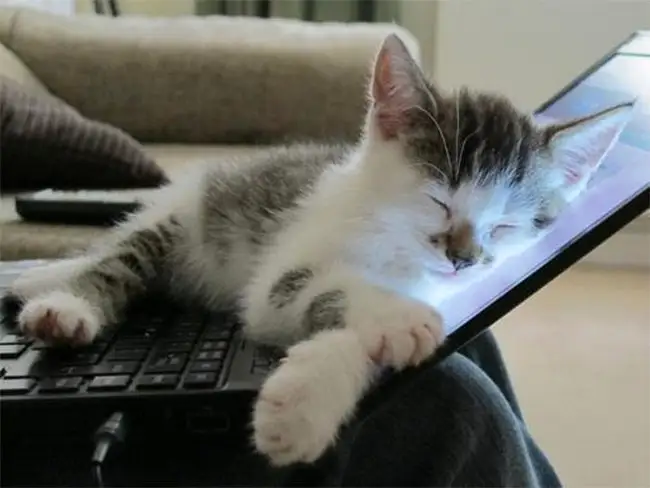